In [33]:
import os
import joblib
import pandas as pd
import numpy as np
from string import punctuation
from nltk.corpus import stopwords
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.tag import pos_tag
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df = pd.read_csv("Symptom2Disease.csv")
df.head()

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."


In [35]:
# preprocess function
def tag_to_wordnet(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def preprocess(sentence):
    tokens = word_tokenize(sentence)
    cleaned_tokens = [
        token.lower()
        for token in tokens
        if token.lower() not in stopwords.words('english')
        and token.lower() not in punctuation
    ]
    tagged_tokens = pos_tag(cleaned_tokens)
    lemmatized_tokens = [
        WordNetLemmatizer().lemmatize(token, tag_to_wordnet(tag))
        for token, tag in tagged_tokens
    ]
    return lemmatized_tokens

df['clean_text'] = df['text'].apply(preprocess)
print(df[['text', 'clean_text']].head())

                                                text  \
0  I have been experiencing a skin rash on my arm...   
1  My skin has been peeling, especially on my kne...   
2  I have been experiencing joint pain in my fing...   
3  There is a silver like dusting on my skin, esp...   
4  My nails have small dents or pits in them, and...   

                                          clean_text  
0  [experience, skin, rash, arm, legs, torso, pas...  
1  [skin, peel, especially, knee, elbow, scalp, p...  
2  [experience, joint, pain, finger, wrists, knee...  
3  [silver, like, dust, skin, especially, low, ba...  
4  [nail, small, dent, pit, often, feel, inflamma...  


In [36]:
X = df['clean_text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
def load_glove_embeddings(path, vector_size=100):
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split(' ')
            if len(parts) != vector_size + 1:
                continue
            word = parts[0]
            vector = np.asarray(parts[1:], dtype=np.float32)
            embeddings[word] = vector
    return embeddings

glove_path = 'glove.6B/glove.6B.100d.txt'
print('Loading GloVe embeddings...')
glove_embeddings = load_glove_embeddings(glove_path, vector_size=100)
print('Loaded embeddings:', len(glove_embeddings))

Loading GloVe embeddings...
Loaded embeddings: 400000


In [38]:
def sentence_vector(tokens, embeddings, vector_size=100):
    vectors = []
    for word in tokens:
        vector = embeddings.get(word)
        if vector is not None:
            vectors.append(vector)
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_glove = np.array([
    sentence_vector(tokens, glove_embeddings, vector_size=100)
    for tokens in X_train
])
X_test_glove = np.array([
    sentence_vector(tokens, glove_embeddings, vector_size=100)
    for tokens in X_test
])
print('Train vectors:', X_train_glove.shape)
print('Test vectors:', X_test_glove.shape)

Train vectors: (960, 100)
Test vectors: (240, 100)


In [39]:
model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)
model.fit(X_train_glove, y_train)

os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/glove_model.joblib", compress=True)

['models/glove_model.joblib']

In [40]:
y_pred = model.predict(X_test_glove)

accuracy = accuracy_score(y_test, y_pred)
print('Accuracy :', accuracy)
print('\nClassification Report\n')
print(classification_report(y_test, y_pred))

weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
    y_test,
    y_pred,
    average='weighted',
    zero_division=0
)

metrics_df = pd.DataFrame([
    {'metric': 'accuracy', 'value': accuracy},
    {'metric': 'weighted_precision', 'value': weighted_precision},
    {'metric': 'weighted_recall', 'value': weighted_recall},
    {'metric': 'weighted_f1', 'value': weighted_f1}
])

print(metrics_df)

Accuracy : 0.9458333333333333

Classification Report

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00         7
                      Arthritis       1.00      1.00      1.00        10
               Bronchial Asthma       1.00      1.00      1.00        11
           Cervical spondylosis       1.00      1.00      1.00         7
                    Chicken pox       0.90      0.75      0.82        12
                    Common Cold       1.00      1.00      1.00        12
                         Dengue       0.83      0.83      0.83        12
          Dimorphic Hemorrhoids       1.00      1.00      1.00         7
               Fungal infection       1.00      0.92      0.96        13
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       0.91      0.91      0.91        11
                       Jaundice       1.00      1.00      1.00       

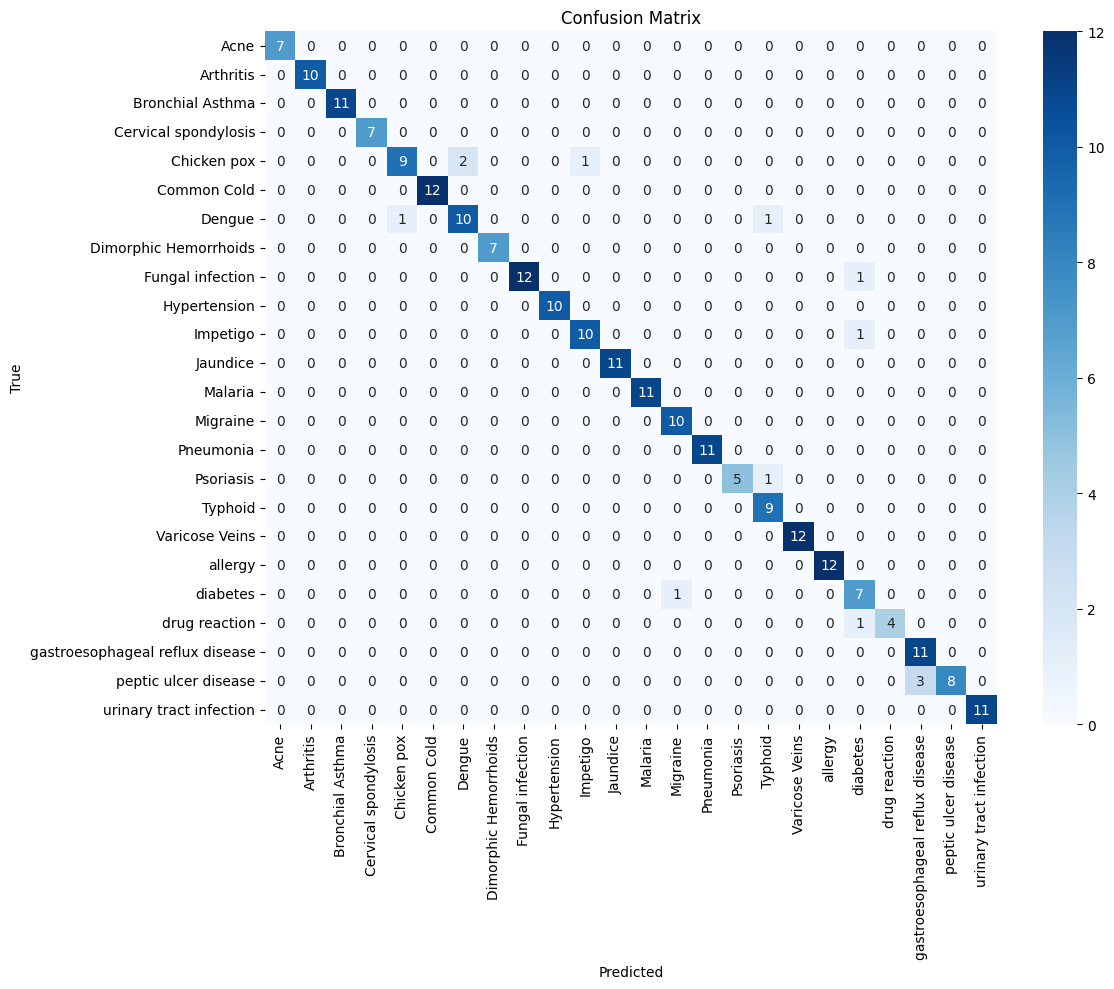

In [41]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()